In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

Load Dataset

In [2]:
file_path = "../datasets/phase_2/paysim-dataset-phase2.parquet"
df = pd.read_parquet(file_path)
df.head()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,origError,destError,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,cluster_kmeans,cluster_hdbscan,cluster_birch,cluster_birch_hdbscan,is_birch_hdbscan_outlier
0,-6.292167,-0.738877,0.214329,-0.857456,0,-2.510411,0.061098,1,0,0,0,0,1,0,2,-1,0,0,0
1,-6.292167,-1.344428,0.034742,-0.857456,0,-2.510411,-0.094642,1,0,0,0,0,1,0,2,-1,0,0,0
2,-6.292167,-2.191764,-0.376195,-0.857456,1,-2.510411,-0.312566,0,1,0,0,0,0,1,2,-1,0,-1,0
3,-6.292167,-2.191764,-0.376195,-0.133384,1,-2.510411,0.133690,0,1,0,1,0,0,0,2,-1,0,-1,0
4,-6.292167,-0.676824,0.092640,-0.857456,0,-2.510411,0.077058,1,0,0,0,0,1,0,2,-1,0,0,0


In [3]:
def discretize_numeric_series(series, col_name, q=5):
    labels_map = {
        1: ["all"],
        2: ["low", "high"],
        3: ["low", "medium", "high"],
        4: ["very_low", "low", "high", "very_high"],
        5: ["very_low", "low", "medium", "high", "very_high"],
    }

    s = pd.to_numeric(series, errors="coerce")

    if s.nunique(dropna=True) <= 1:
        return None

    try:
        codes, bins = pd.qcut(
            s,
            q=q,
            labels=False,
            retbins=True,
            duplicates="drop"
        )

        n_bins = len(bins) - 1

        if n_bins <= 0:
            return None

        labels = labels_map.get(n_bins, [f"bin_{i}" for i in range(n_bins)])
        mapped = codes.map(lambda x: f"{col_name}_{labels[int(x)]}" if pd.notna(x) else np.nan)

        categories = [f"{col_name}_{label}" for label in labels]
        return pd.Categorical(mapped, categories=categories)

    except Exception as e:
        print(f"Failed to discretize {col_name}: {e}")
        return None

Proses discretization membuat data numerik menjadi item kategorikal agar dapat diproses oleh algoritma seperti Apriori atau FP-Growth. Discretization perlu dilakukan karena Association Rule Mining bekerja dengan data kategorikal, bukan kontinu. 

In [4]:
def build_basket(df):
    basket_parts = []

    type_cols = [col for col in df.columns if col.startswith("type_")]
    if type_cols:
        basket_parts.append(df[type_cols].astype(bool))

    if "isFraud" in df.columns:
        fraud_items = pd.DataFrame(index=df.index)
        fraud_items["isFraud_yes"] = df["isFraud"].astype(int) == 1
        fraud_items["isFraud_no"] = df["isFraud"].astype(int) == 0
        basket_parts.append(fraud_items)

    if "isDestMerchant" in df.columns:
        merchant_items = pd.DataFrame(index=df.index)
        merchant_items["dest_merchant_yes"] = df["isDestMerchant"].astype(int) == 1
        merchant_items["dest_merchant_no"] = df["isDestMerchant"].astype(int) == 0
        basket_parts.append(merchant_items)

    if "origDrainedToZero" in df.columns:
        drained_items = pd.DataFrame(index=df.index)
        drained_items["orig_drained_yes"] = df["origDrainedToZero"].astype(int) == 1
        drained_items["orig_drained_no"] = df["origDrainedToZero"].astype(int) == 0
        basket_parts.append(drained_items)

    if "cluster_kmeans" in df.columns:
        cluster_items = pd.get_dummies(
            df["cluster_kmeans"].astype(str),
            prefix="cluster_kmeans"
        ).astype(bool)
        basket_parts.append(cluster_items)

    if "is_birch_hdbscan_outlier" in df.columns:
        hdbscan_items = pd.DataFrame(index=df.index)
        hdbscan_items["hdbscan_outlier"] = df["is_birch_hdbscan_outlier"] == 1
        hdbscan_items["hdbscan_normal"] = df["is_birch_hdbscan_outlier"] == 0
        basket_parts.append(hdbscan_items)

    numeric_cols = [
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "origError",
        "destError"
    ]

    for col in numeric_cols:
        if col in df.columns:
            cat = discretize_numeric_series(df[col], col_name=col, q=5)

            if cat is not None:
                dummies = pd.get_dummies(cat).astype(bool)
                basket_parts.append(dummies)
                print(f"Discretized {col}: {list(dummies.columns)}")
            else:
                print(f"Skipped {col}: not enough unique values")

    basket = pd.concat(basket_parts, axis=1)
    basket = basket.fillna(False).astype(bool)

    basket = basket.loc[:, basket.any(axis=0)]

    return basket


basket = build_basket(df)

print("Basket shape:", basket.shape)
display(basket.head())

Discretized amount: ['amount_very_low', 'amount_low', 'amount_medium', 'amount_high', 'amount_very_high']
Discretized oldbalanceOrg: ['oldbalanceOrg_very_low', 'oldbalanceOrg_low', 'oldbalanceOrg_high', 'oldbalanceOrg_very_high']
Discretized oldbalanceDest: ['oldbalanceDest_low', 'oldbalanceDest_medium', 'oldbalanceDest_high']
Discretized origError: ['origError_very_low', 'origError_low', 'origError_medium', 'origError_high', 'origError_very_high']
Discretized destError: ['destError_very_low', 'destError_low', 'destError_high', 'destError_very_high']
Basket shape: (6362604, 39)


,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud_yes,isFraud_no,dest_merchant_yes,dest_merchant_no,orig_drained_yes,...,oldbalanceDest_high,origError_very_low,origError_low,origError_medium,origError_high,origError_very_high,destError_very_low,destError_low,destError_high,destError_very_high
0,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,False,False,False,True,False,False
1,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,False,False,False,True,False,False
2,False,False,False,False,True,True,False,False,True,True,...,False,True,False,False,False,False,False,True,False,False
3,False,True,False,False,False,True,False,False,True,True,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,False,False,False,False,True,False


Function build_basket bertujuan untuk mengubah dataset transaksi menjadi basket/transaction matrix, yaitu format yang dibutuhkan oleh algoritma seperti Apriori atau FP-Growth (diubah jadi seperti one-hot encoding, tetapi semua fitur diubah menjadi item transaksi). Algoritma Apriori dan FP-Growth tidak bekerja pada tabel transaksi biasa. Mereka mencari pola berdasarkan keberadaan item dalam setiap transaksi. Apriori dan FP-Growth perlu menggunakan transaction item matrix agar dapat menghitung support, confidence, maupun lift karena belum memiliki representasi item yang dapat dibandingkan antar transaksi.

,support
isFraud_no,0.998712
hdbscan_normal,0.997178
orig_drained_no,0.761013
dest_merchant_no,0.661853
oldbalanceDest_low,0.600000
destError_very_low,0.400000
oldbalanceOrg_very_low,0.400000
type_CASH_OUT,0.351662
type_PAYMENT,0.338147
dest_merchant_yes,0.338147


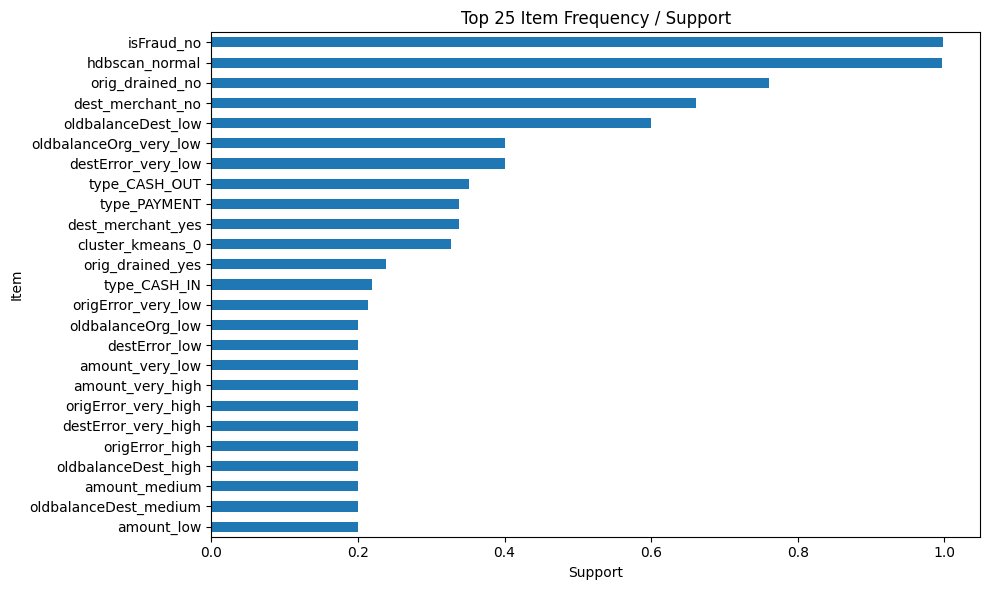

In [5]:
item_frequency = basket.mean().sort_values(ascending=False).to_frame("support")
display(item_frequency)

plt.figure(figsize=(10, 6))
item_frequency.head(25)["support"].sort_values().plot(kind="barh")
plt.title("Top 25 Item Frequency / Support")
plt.xlabel("Support")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

Kode diatas menghitung support tiap item dan mengurutkannya agar dapat melihat seberapa sering setiap item muncul pada seluruh transaksi sebelum menjalankan algoritma Apriori atau FP-Growth. Association Rule Mining menggunakan metriks utama yaitu support, sehingga sebelum mencari rules, perlu diketahui distribusi support dari setiap item. Proses ini dapat membantu untuk menentukan minimum support yang tepat dan mengidentifikasi item yang terlalu langka atau terlalu dominan sehingga dapat memengaruhi kualitas aturan asosiasi yang dihasilkan.

In [6]:
MIN_SUPPORT = 0.005
MIN_CONFIDENCE = 0.50
MIN_LIFT = 1.20
MAX_LEN = 3

In [7]:
frequent_itemsets = apriori(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_LEN,
    low_memory=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

print("Frequent itemsets found:", len(frequent_itemsets))
display(frequent_itemsets.head(20))

Frequent itemsets found: 3406


,support,itemsets
0,0.998712,(isFraud_no)
1,0.997178,(hdbscan_normal)
2,0.996137,"(isFraud_no, hdbscan_normal)"
3,0.761013,(orig_drained_no)
4,0.760984,"(isFraud_no, orig_drained_no)"
5,0.758438,"(orig_drained_no, hdbscan_normal)"
6,0.758409,"(isFraud_no, orig_drained_no, hdbscan_normal)"
7,0.661853,(dest_merchant_no)
8,0.660565,"(isFraud_no, dest_merchant_no)"
9,0.659031,"(dest_merchant_no, hdbscan_normal)"


In [8]:
if len(frequent_itemsets) == 0:
    raise ValueError("No frequent itemsets found. Coba turunkan MIN_SUPPORT.")

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=MIN_LIFT
)

rules = rules[
    (rules["confidence"] >= MIN_CONFIDENCE) &
    (rules["lift"] >= MIN_LIFT)
].copy()

rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)

rules = rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Rules generated after filtering:", len(rules))
display(rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Rules generated after filtering: 2858


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
1,type_DEBIT,"amount_very_low, dest_merchant_no",0.005905,0.906763,35.560732,0.005739,10.451858
2,"cluster_kmeans_0, origError_very_high",type_TRANSFER,0.043408,0.546870,6.529291,0.036760,2.022033
3,type_TRANSFER,"cluster_kmeans_0, origError_very_high",0.043408,0.518265,6.529291,0.036760,1.911060
4,"destError_very_low, origError_very_high",type_TRANSFER,0.046365,0.542498,6.477090,0.039206,2.002709
5,type_TRANSFER,"destError_very_low, origError_very_high",0.046365,0.553564,6.477090,0.039206,2.048523
6,"origError_very_high, orig_drained_yes",type_TRANSFER,0.023547,0.527691,6.300308,0.019810,1.939925
7,"dest_merchant_yes, origError_medium",cluster_kmeans_4,0.024131,0.905175,6.105433,0.020178,8.982222
8,"origError_medium, type_PAYMENT",cluster_kmeans_4,0.024131,0.905175,6.105433,0.020178,8.982222
9,"orig_drained_yes, type_PAYMENT",cluster_kmeans_4,0.043996,0.856378,5.776299,0.036380,5.930450


In [9]:
def filter_meaningful_rules(rules):
    if len(rules) == 0:
        return rules.copy()

    filtered = rules.copy()

    trivial_consequents = [
        "isFraud_no",
        "hdbscan_normal",
        "orig_drained_no",
        "dest_merchant_no"
    ]

    for keyword in trivial_consequents:
        filtered = filtered[
            ~filtered["consequents_str"].str.contains(keyword, regex=False, na=False)
        ]

    important_mask = (
        filtered["consequents_str"].str.contains("isFraud_yes", regex=False, na=False) |
        filtered["consequents_str"].str.contains("hdbscan_outlier", regex=False, na=False) |
        filtered["consequents_str"].str.contains("cluster_kmeans", regex=False, na=False) |
        filtered["consequents_str"].str.contains("very_high", regex=False, na=False) |
        filtered["consequents_str"].str.contains("very_low", regex=False, na=False) |
        filtered["consequents_str"].str.contains("orig_drained_yes", regex=False, na=False) |
        filtered["consequents_str"].str.contains("dest_merchant_yes", regex=False, na=False)
    )

    filtered = filtered[important_mask].copy()

    return filtered.sort_values(
        by=["lift", "confidence", "support"],
        ascending=[False, False, False]
    ).reset_index(drop=True)


meaningful_rules = filter_meaningful_rules(rules)

print("Meaningful rules:", len(meaningful_rules))
display(meaningful_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Meaningful rules: 1203


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
1,type_TRANSFER,"cluster_kmeans_0, origError_very_high",0.043408,0.518265,6.529291,0.036760,1.911060
2,type_TRANSFER,"destError_very_low, origError_very_high",0.046365,0.553564,6.477090,0.039206,2.048523
3,"dest_merchant_yes, origError_medium",cluster_kmeans_4,0.024131,0.905175,6.105433,0.020178,8.982222
4,"origError_medium, type_PAYMENT",cluster_kmeans_4,0.024131,0.905175,6.105433,0.020178,8.982222
5,"orig_drained_yes, type_PAYMENT",cluster_kmeans_4,0.043996,0.856378,5.776299,0.036380,5.930450
6,"dest_merchant_yes, orig_drained_yes",cluster_kmeans_4,0.043996,0.856378,5.776299,0.036380,5.930450
7,"dest_merchant_yes, oldbalanceOrg_very_low",cluster_kmeans_4,0.122619,0.841228,5.674113,0.101009,5.364576
8,"oldbalanceOrg_very_low, type_PAYMENT",cluster_kmeans_4,0.122619,0.841228,5.674113,0.101009,5.364576
9,cluster_kmeans_4,"dest_merchant_yes, oldbalanceOrg_very_low",0.122619,0.827070,5.674113,0.101009,4.939797


In [10]:
report_rules = meaningful_rules.copy()

report_rules = report_rules[
    ~report_rules["consequents_str"].str.contains(
        "isFraud_no|hdbscan_normal|orig_drained_no|dest_merchant_no",
        regex=True,
        na=False
    )
].copy()

report_rules = report_rules[
    (report_rules["confidence"] >= 0.30) &
    (report_rules["lift"] >= 1.20)
].copy()

report_rules = report_rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Report-worthy rules:", len(report_rules))

display(report_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(30))

Report-worthy rules: 1203


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685e+00
1,type_TRANSFER,"cluster_kmeans_0, origError_very_high",0.043408,0.518265,6.529291,0.036760,1.911060e+00
2,type_TRANSFER,"destError_very_low, origError_very_high",0.046365,0.553564,6.477090,0.039206,2.048523e+00
3,"dest_merchant_yes, origError_medium",cluster_kmeans_4,0.024131,0.905175,6.105433,0.020178,8.982222e+00
4,"origError_medium, type_PAYMENT",cluster_kmeans_4,0.024131,0.905175,6.105433,0.020178,8.982222e+00
5,"orig_drained_yes, type_PAYMENT",cluster_kmeans_4,0.043996,0.856378,5.776299,0.036380,5.930450e+00
6,"dest_merchant_yes, orig_drained_yes",cluster_kmeans_4,0.043996,0.856378,5.776299,0.036380,5.930450e+00
7,"dest_merchant_yes, oldbalanceOrg_very_low",cluster_kmeans_4,0.122619,0.841228,5.674113,0.101009,5.364576e+00
8,"oldbalanceOrg_very_low, type_PAYMENT",cluster_kmeans_4,0.122619,0.841228,5.674113,0.101009,5.364576e+00
9,cluster_kmeans_4,"dest_merchant_yes, oldbalanceOrg_very_low",0.122619,0.827070,5.674113,0.101009,4.939797e+00


In [11]:
payment_rules = report_rules[
    report_rules["antecedents_str"].str.contains("type_PAYMENT", na=False)
    | report_rules["consequents_str"].str.contains("type_PAYMENT", na=False)
].sort_values("lift", ascending=False)

print(f"Jumlah rule terkait PAYMENT: {len(payment_rules)}")
display(payment_rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]].head(5))

Jumlah rule terkait PAYMENT: 81


,antecedents_str,consequents_str,support,confidence,lift
4,"origError_medium, type_PAYMENT",cluster_kmeans_4,0.024131,0.905175,6.105433
5,"orig_drained_yes, type_PAYMENT",cluster_kmeans_4,0.043996,0.856378,5.776299
8,"oldbalanceOrg_very_low, type_PAYMENT",cluster_kmeans_4,0.122619,0.841228,5.674113
10,cluster_kmeans_4,"oldbalanceOrg_very_low, type_PAYMENT",0.122619,0.827070,5.674113
12,"origError_low, type_PAYMENT",cluster_kmeans_4,0.122888,0.839448,5.662102


In [12]:
important_items = [
    "isFraud_yes",
    "isFraud_no",
    "hdbscan_outlier",
    "hdbscan_normal",
    "orig_drained_yes",
    "orig_drained_no",
    "dest_merchant_yes",
    "dest_merchant_no"
]

for item in important_items:
    if item in basket.columns:
        print(f"{item}: {basket[item].mean():.6f} ({basket[item].mean() * 100:.4f}%)")

isFraud_yes: 0.001288 (0.1288%)
isFraud_no: 0.998712 (99.8712%)
hdbscan_outlier: 0.002822 (0.2822%)
hdbscan_normal: 0.997178 (99.7178%)
orig_drained_yes: 0.238987 (23.8987%)
orig_drained_no: 0.761013 (76.1013%)
dest_merchant_yes: 0.338147 (33.8147%)
dest_merchant_no: 0.661853 (66.1853%)


In [13]:
fraud_itemsets = apriori(
    basket,
    min_support=0.0001,
    use_colnames=True,
    max_len=3,
    low_memory=True
)

fraud_rules = association_rules(
    fraud_itemsets,
    metric="lift",
    min_threshold=1.2
)

fraud_rules["antecedents_str"] = fraud_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

fraud_rules["consequents_str"] = fraud_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

fraud_rules = fraud_rules[
    fraud_rules["consequents_str"].str.contains("isFraud_yes", regex=False, na=False)
].copy()

fraud_rules = fraud_rules[
    ~fraud_rules["antecedents_str"].str.contains(
        "isFraud_no",
        regex=True,
        na=False
    )
].copy()

fraud_rules = fraud_rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Fraud rules:", len(fraud_rules))

display(fraud_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Fraud rules: 291


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"origError_very_low, orig_drained_yes",isFraud_yes,0.001259,1.000000,776.211297,0.001257,inf
1,"hdbscan_outlier, orig_drained_yes",isFraud_yes,0.000247,1.000000,776.211297,0.000247,inf
2,"cluster_kmeans_1, orig_drained_yes",isFraud_yes,0.001145,0.827089,641.995833,0.001143,5.775872
3,"destError_very_high, hdbscan_outlier",isFraud_yes,0.000157,0.733333,569.221618,0.000157,3.745169
4,"cluster_kmeans_1, destError_very_high",isFraud_yes,0.000469,0.324766,252.086919,0.000467,1.479060
5,"amount_very_high, cluster_kmeans_1",isFraud_yes,0.000733,0.229275,177.966038,0.000729,1.295809
6,"amount_very_high, hdbscan_outlier",isFraud_yes,0.000105,0.204797,158.965782,0.000104,1.255921
7,"amount_very_high, origError_very_low",isFraud_yes,0.000802,0.194208,150.746166,0.000797,1.239416
8,"cluster_kmeans_1, type_TRANSFER",isFraud_yes,0.000592,0.178688,138.699870,0.000588,1.215996
9,hdbscan_outlier,"isFraud_yes, type_TRANSFER",0.000247,0.087557,135.975371,0.000245,1.095253


In [14]:
selected_parts = []

if "fraud_rules" in globals() and len(fraud_rules) > 0:
    selected_parts.append(fraud_rules.head(4))

outlier_rules = report_rules[
    report_rules["consequents_str"].str.contains("hdbscan_outlier", regex=False, na=False)
].copy()

if len(outlier_rules) > 0:
    selected_parts.append(outlier_rules.head(2))

cluster_rules = report_rules[
    report_rules["consequents_str"].str.contains("cluster_kmeans", regex=False, na=False)
].copy()

if len(cluster_rules) > 0:
    selected_parts.append(cluster_rules.head(2))

general_rules = report_rules[
    ~report_rules["consequents_str"].str.contains(
        "isFraud_yes|hdbscan_outlier|cluster_kmeans",
        regex=True,
        na=False
    )
].copy()

if len(general_rules) > 0:
    selected_parts.append(general_rules.head(5))

top_10_final = pd.concat(selected_parts, ignore_index=True)

top_10_final = top_10_final.drop_duplicates(
    subset=["antecedents_str", "consequents_str"]
)

if len(top_10_final) < 10:
    filler = report_rules[
        ~report_rules.set_index(["antecedents_str", "consequents_str"]).index.isin(
            top_10_final.set_index(["antecedents_str", "consequents_str"]).index
        )
    ].copy()

    top_10_final = pd.concat(
        [top_10_final, filler.head(10 - len(top_10_final))],
        ignore_index=True
    )

top_10_final = top_10_final.head(10).copy()

display(top_10_final[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]])

,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"origError_very_low, orig_drained_yes",isFraud_yes,0.001259,1.000000,776.211297,0.001257,inf
1,"hdbscan_outlier, orig_drained_yes",isFraud_yes,0.000247,1.000000,776.211297,0.000247,inf
2,"cluster_kmeans_1, orig_drained_yes",isFraud_yes,0.001145,0.827089,641.995833,0.001143,5.775872
3,"destError_very_high, hdbscan_outlier",isFraud_yes,0.000157,0.733333,569.221618,0.000157,3.745169
4,type_TRANSFER,"cluster_kmeans_0, origError_very_high",0.043408,0.518265,6.529291,0.036760,1.911060
5,"dest_merchant_yes, origError_medium",cluster_kmeans_4,0.024131,0.905175,6.105433,0.020178,8.982222
6,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
7,type_TRANSFER,"destError_very_low, origError_very_high",0.046365,0.553564,6.477090,0.039206,2.048523
8,cluster_kmeans_4,"dest_merchant_yes, oldbalanceOrg_very_low",0.122619,0.827070,5.674113,0.101009,4.939797
9,cluster_kmeans_4,"oldbalanceOrg_very_low, type_PAYMENT",0.122619,0.827070,5.674113,0.101009,4.939797


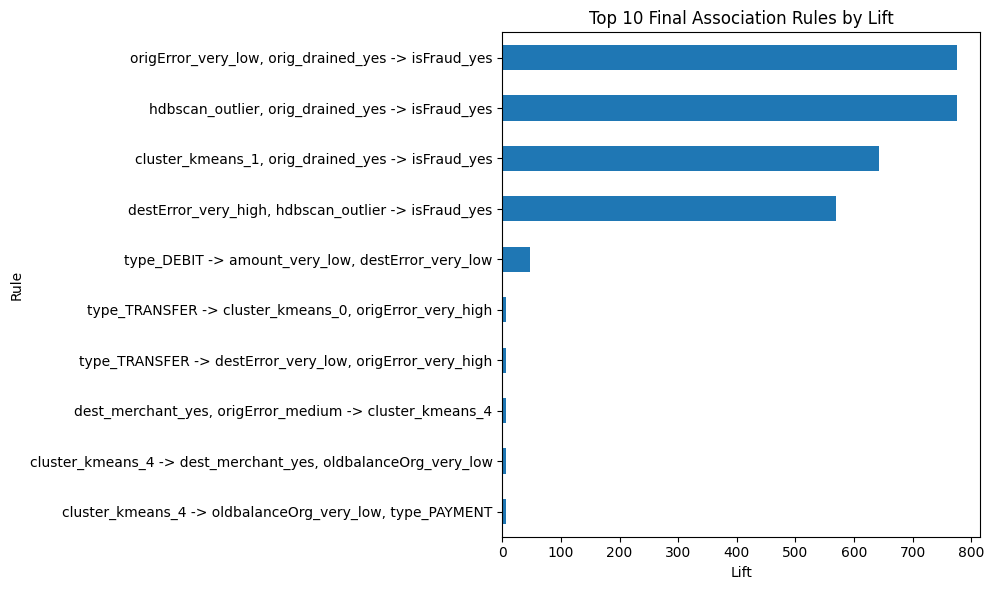

In [15]:
if len(top_10_final) > 0:
    plot_df = top_10_final.copy()
    plot_df["rule"] = plot_df["antecedents_str"] + " -> " + plot_df["consequents_str"]

    plt.figure(figsize=(10, 6))
    plot_df.set_index("rule")["lift"].sort_values().plot(kind="barh")
    plt.title("Top 10 Final Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")
    plt.tight_layout()
    plt.show()
else:
    print("No top rules available to plot.")

In [16]:
top_10_final = top_10_final[
    ~top_10_final["antecedents_str"].str.contains(
        "isFraud_no|hdbscan_normal|orig_drained_no",
        regex=True,
        na=False
    )
].copy()

if len(top_10_final) < 10:
    existing_pairs = set(
        zip(top_10_final["antecedents_str"], top_10_final["consequents_str"])
    )

    filler = report_rules[
        ~report_rules["antecedents_str"].str.contains(
            "isFraud_no|hdbscan_normal|orig_drained_no",
            regex=True,
            na=False
        )
    ].copy()

    filler = filler[
        ~filler.apply(
            lambda row: (row["antecedents_str"], row["consequents_str"]) in existing_pairs,
            axis=1
        )
    ]

    top_10_final = pd.concat(
        [top_10_final, filler.head(10 - len(top_10_final))],
        ignore_index=True
    )

top_10_final = top_10_final.head(10).copy()

display(top_10_final[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]])

,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"origError_very_low, orig_drained_yes",isFraud_yes,0.001259,1.000000,776.211297,0.001257,inf
1,"hdbscan_outlier, orig_drained_yes",isFraud_yes,0.000247,1.000000,776.211297,0.000247,inf
2,"cluster_kmeans_1, orig_drained_yes",isFraud_yes,0.001145,0.827089,641.995833,0.001143,5.775872
3,"destError_very_high, hdbscan_outlier",isFraud_yes,0.000157,0.733333,569.221618,0.000157,3.745169
4,type_TRANSFER,"cluster_kmeans_0, origError_very_high",0.043408,0.518265,6.529291,0.036760,1.911060
5,"dest_merchant_yes, origError_medium",cluster_kmeans_4,0.024131,0.905175,6.105433,0.020178,8.982222
6,type_DEBIT,"amount_very_low, destError_very_low",0.005420,0.832352,47.200336,0.005305,5.859685
7,type_TRANSFER,"destError_very_low, origError_very_high",0.046365,0.553564,6.477090,0.039206,2.048523
8,cluster_kmeans_4,"dest_merchant_yes, oldbalanceOrg_very_low",0.122619,0.827070,5.674113,0.101009,4.939797
9,cluster_kmeans_4,"oldbalanceOrg_very_low, type_PAYMENT",0.122619,0.827070,5.674113,0.101009,4.939797


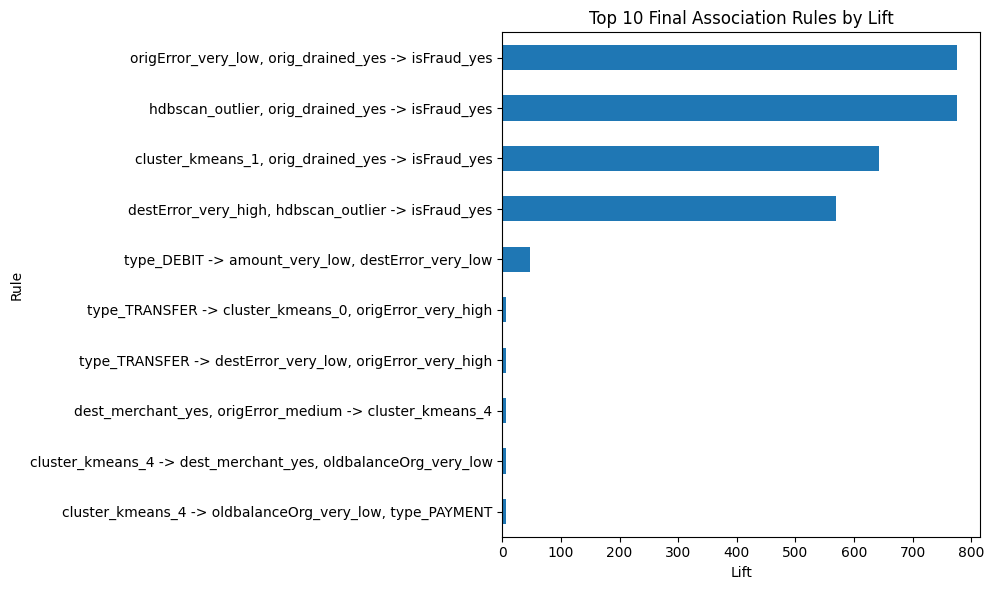

In [17]:
if len(top_10_final) > 0:
    plot_df = top_10_final.copy()
    plot_df["rule"] = plot_df["antecedents_str"] + " -> " + plot_df["consequents_str"]

    plt.figure(figsize=(10, 6))
    plot_df.set_index("rule")["lift"].sort_values().plot(kind="barh")
    plt.title("Top 10 Final Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")
    plt.tight_layout()
    plt.show()
else:
    print("No top rules available to plot.")